# Tomato Disease Detection - Fixed Version V2
### All fixes applied for correct predictions and faster convergence

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
import os

print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

np.random.seed(42)
tf.random.set_seed(42)


TensorFlow Version: 2.15.0
GPU Available: []


## ✅ FIX 1: Hyperparameters — IMAGE_SIZE increased, LR reduced

In [2]:
# ✅ FIX 1: Key hyperparameter changes
IMAGE_SIZE = 224        # CHANGED from 128 → 224 (more detail for disease patterns)
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 30             # CHANGED from 50 → 30 (EarlyStopping will stop even earlier)
LEARNING_RATE = 0.0001  # CHANGED from 0.001 → 0.0001 (was too high, causing no learning)

# Dataset path - CHANGE THIS TO YOUR PATH
DATASET_PATH = r"D:\Major_Project_2\Dataset_Balanced"
MODEL_SAVE_PATH = "best_tomato_disease_model.keras"

print(f"Image Size  : {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"Epochs      : {EPOCHS}")
print(f"Learning Rate: {LEARNING_RATE}")

Image Size  : 224x224
Epochs      : 30
Learning Rate: 0.0001


In [3]:
# Load dataset
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    seed=42
)

class_names = dataset.class_names
n_classes = len(class_names)

print(f"Number of classes : {n_classes}")
print(f"Class names       : {class_names}")
print(f"Total batches     : {len(dataset)}")

Found 12729 files belonging to 10 classes.
Number of classes : 10
Class names       : ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']
Total batches     : 398


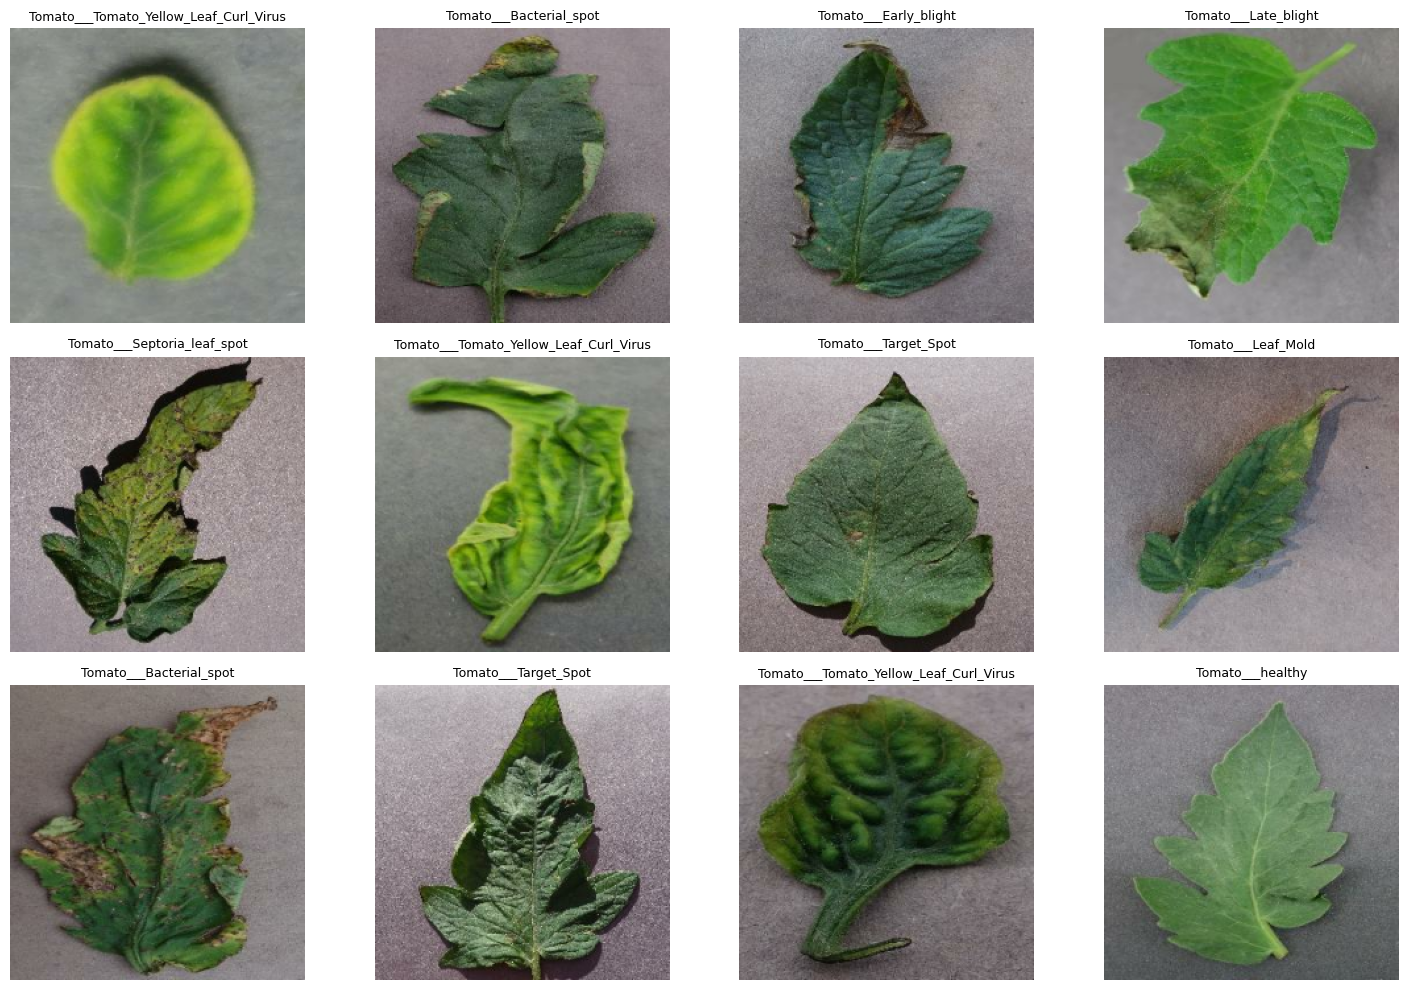

In [4]:
# Visualize sample images
plt.figure(figsize=(15, 10))
for image_batch, label_batch in dataset.take(1):
    for i in range(min(12, len(image_batch))):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]], fontsize=9)
        plt.axis("off")
plt.tight_layout()
plt.show()

In [5]:
# Split dataset 80/10/10
def get_dataset_partitions(ds, train_split=0.8, val_split=0.1, test_split=0.1,
                            shuffle=True, shuffle_size=10000):
    assert (train_split + val_split + test_split) == 1.0
    ds_size = len(ds)
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=42, reshuffle_each_iteration=False)
    train_size = int(train_split * ds_size)
    val_size   = int(val_split   * ds_size)
    train_ds = ds.take(train_size)
    val_ds   = ds.skip(train_size).take(val_size)
    test_ds  = ds.skip(train_size + val_size)
    return train_ds, val_ds, test_ds

train_ds, val_ds, test_ds = get_dataset_partitions(dataset)

print(f"Training batches  : {len(train_ds)}")
print(f"Validation batches: {len(val_ds)}")
print(f"Test batches      : {len(test_ds)}")

Training batches  : 318
Validation batches: 39
Test batches      : 41


In [6]:
# Class weights for imbalanced data
train_labels = []
for _, labels in train_ds:
    train_labels.extend(labels.numpy())
train_labels = np.array(train_labels)

class_weights_values = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = dict(enumerate(class_weights_values))

print("Class weights:")
for i, weight in class_weights.items():
    print(f"  {class_names[i]}: {weight:.3f}")

Class weights:
  Tomato___Bacterial_spot: 0.840
  Tomato___Early_blight: 1.284
  Tomato___Late_blight: 0.852
  Tomato___Leaf_Mold: 1.361
  Tomato___Septoria_leaf_spot: 0.852
  Tomato___Spider_mites Two-spotted_spider_mite: 0.841
  Tomato___Target_Spot: 0.910
  Tomato___Tomato_Yellow_Leaf_Curl_Virus: 0.850
  Tomato___Tomato_mosaic_virus: 3.401
  Tomato___healthy: 0.840


In [7]:
# Check actual image counts per class
import pathlib

data_dir = pathlib.Path(DATASET_PATH)
print("Image counts per class:")
for folder in sorted(data_dir.iterdir()):
    if folder.is_dir():
        count = len(list(folder.glob('*')))
        print(f"  {folder.name}: {count} images")

Image counts per class:
  Tomato___Bacterial_spot: 1500 images
  Tomato___Early_blight: 1000 images
  Tomato___healthy: 1500 images
  Tomato___Late_blight: 1500 images
  Tomato___Leaf_Mold: 952 images
  Tomato___Septoria_leaf_spot: 1500 images
  Tomato___Spider_mites Two-spotted_spider_mite: 1500 images
  Tomato___Target_Spot: 1404 images
  Tomato___Tomato_mosaic_virus: 373 images
  Tomato___Tomato_Yellow_Leaf_Curl_Virus: 1500 images


In [8]:
# Clip extreme class weights between 0.5 and 3.0
for k in class_weights:
    class_weights[k] = float(np.clip(class_weights[k], 0.5, 3.0))

print("Clipped class weights:")
for i, w in class_weights.items():
    print(f"  {class_names[i]}: {w:.3f}")

Clipped class weights:
  Tomato___Bacterial_spot: 0.840
  Tomato___Early_blight: 1.284
  Tomato___Late_blight: 0.852
  Tomato___Leaf_Mold: 1.361
  Tomato___Septoria_leaf_spot: 0.852
  Tomato___Spider_mites Two-spotted_spider_mite: 0.841
  Tomato___Target_Spot: 0.910
  Tomato___Tomato_Yellow_Leaf_Curl_Virus: 0.850
  Tomato___Tomato_mosaic_virus: 3.000
  Tomato___healthy: 0.840


Do not run this below command block

In [9]:
import shutil, random, pathlib

src = pathlib.Path(DATASET_PATH)
dst = pathlib.Path(r"C:\Users\hunny\OneDrive\Desktop\Major_Project_2\Dataset_Balanced")
MAX_PER_CLASS = 1500  # cap every class at 1500 images

for folder in src.iterdir():
    if not folder.is_dir():
        continue
    images = list(folder.glob('*'))
    selected = random.sample(images, min(len(images), MAX_PER_CLASS))
    out_folder = dst / folder.name
    out_folder.mkdir(parents=True, exist_ok=True)
    for img in selected:
        shutil.copy(img, out_folder / img.name)

print("✅ Balanced dataset created at Dataset_Balanced")
print("Now change DATASET_PATH to Dataset_Balanced and rerun")

✅ Balanced dataset created at Dataset_Balanced
Now change DATASET_PATH to Dataset_Balanced and rerun


## ✅ FIX 2: Simplified Augmentation — removed aggressive stacking

In [9]:
# ✅ FIX 2: Reduced augmentation
# BEFORE: 5 augmentations stacked (too aggressive, images became unrecognizable)
# AFTER : Only 2 mild augmentations
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),       # only horizontal, not vertical
    layers.RandomRotation(0.1),            # CHANGED 0.3 → 0.1 (mild rotation)
    # Removed: RandomZoom, RandomContrast, RandomBrightness
], name="data_augmentation")

normalization = layers.Rescaling(1./255, name="normalization")

def prepare_dataset(ds, augment=False):
    ds = ds.map(lambda x, y: (normalization(x), y),
                num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    return ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

train_ds_prepared = prepare_dataset(train_ds, augment=True)
val_ds_prepared   = prepare_dataset(val_ds,   augment=False)
test_ds_prepared  = prepare_dataset(test_ds,  augment=False)

print("✅ Datasets prepared")


✅ Datasets prepared


## ✅ FIX 3: Lighter CNN — fewer blocks, weaker L2, more Dropout

In [10]:
# ✅ FIX 3: Redesigned CNN architecture
# BEFORE: 5 conv blocks with l2(0.001) on every layer → too regularized, model couldn't learn
# AFTER : 4 conv blocks with l2(0.0001) → lighter penalty, model can actually learn

def build_custom_cnn(input_shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS), num_classes=n_classes):

    model = models.Sequential([
        layers.Input(shape=input_shape),

        # Block 1 — learn basic edges and colors
        layers.Conv2D(32, (3,3), padding='same',
                      kernel_regularizer=regularizers.l2(0.0001)),  # CHANGED 0.001 → 0.0001
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Block 2 — learn textures
        layers.Conv2D(64, (3,3), padding='same',
                      kernel_regularizer=regularizers.l2(0.0001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Block 3 — learn disease patterns
        layers.Conv2D(128, (3,3), padding='same',
                      kernel_regularizer=regularizers.l2(0.0001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.3),

        # Block 4 — learn complex disease features
        layers.Conv2D(256, (3,3), padding='same',
                      kernel_regularizer=regularizers.l2(0.0001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.3),

        # Classifier head
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(0.0001)),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

model = build_custom_cnn()
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 224, 224, 32)      896       
                                                                 
 batch_normalization (Batch  (None, 224, 224, 32)      128       
 Normalization)                                                  
                                                                 
 activation (Activation)     (None, 224, 224, 32)      0         
                                                                 
 max_pooling2d (MaxPooling2  (None, 112, 112, 32)      0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 112, 112, 32)      0         
                                                                 
 conv2d_1 (Conv2D)           (None, 112, 112, 64)      

## ✅ FIX 4: Lower Learning Rate in optimizer

In [11]:
# ✅ FIX 4: Lower learning rate
# BEFORE: 0.001 → model was overshooting, accuracy stuck at 0.09
# AFTER : 0.0001 → smoother learning

optimizer = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE,  # 0.0001
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-07
)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model compiled")

✅ Model compiled


## ✅ FIX 5: EarlyStopping now monitors val_accuracy, patience reduced to 7

In [12]:
# ✅ FIX 5: Better callbacks
# BEFORE: EarlyStopping monitored val_loss with patience=10
# AFTER : monitors val_accuracy with patience=7 → stops faster if not improving

callbacks = [
    ModelCheckpoint(
        MODEL_SAVE_PATH,
        monitor='val_accuracy',      # CHANGED from val_loss → val_accuracy
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',      # CHANGED from val_loss → val_accuracy
        patience=7,                  # CHANGED from 10 → 7
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,                  # CHANGED from 5 → 3 (reduce LR faster)
        min_lr=1e-7,
        verbose=1
    )
]

print("✅ Callbacks configured")

✅ Callbacks configured


In [13]:
# Train the model
print("🚀 Starting training...\n")
print("Watch epoch 1 — accuracy should be 0.40+ if fixes worked\n")

history = model.fit(
    train_ds_prepared,
    validation_data=val_ds_prepared,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

print("\n✅ Training completed!")
print(f"Stopped at epoch: {len(history.history['accuracy'])}")

🚀 Starting training...

Watch epoch 1 — accuracy should be 0.40+ if fixes worked

Epoch 1/30


318/318 [==============================] - ETA: 0s - loss: 1.5823 - accuracy: 0.4687
Epoch 1: val_accuracy improved from -inf to 0.12821, saving model to best_tomato_disease_model.keras
318/318 [==============================] - 349s 1s/step - loss: 1.5823 - accuracy: 0.4687 - val_loss: 3.3457 - val_accuracy: 0.1282 - lr: 1.0000e-04
Epoch 2/30
318/318 [==============================] - ETA: 0s - loss: 1.0755 - accuracy: 0.6439
Epoch 2: val_accuracy improved from 0.12821 to 0.50962, saving model to best_tomato_disease_model.keras
318/318 [==============================] - 419s 1s/step - loss: 1.0755 - accuracy: 0.6439 - val_loss: 1.4798 - val_accuracy: 0.5096 - lr: 1.0000e-04
Epoch 3/30
318/318 [==============================] - ETA: 0s - loss: 0.9068 - accuracy: 0.7113
Epoch 3: val_accuracy improved from 0.50962 to 0.62420, saving model to best_tomato_disease_model.keras
318/318 [============

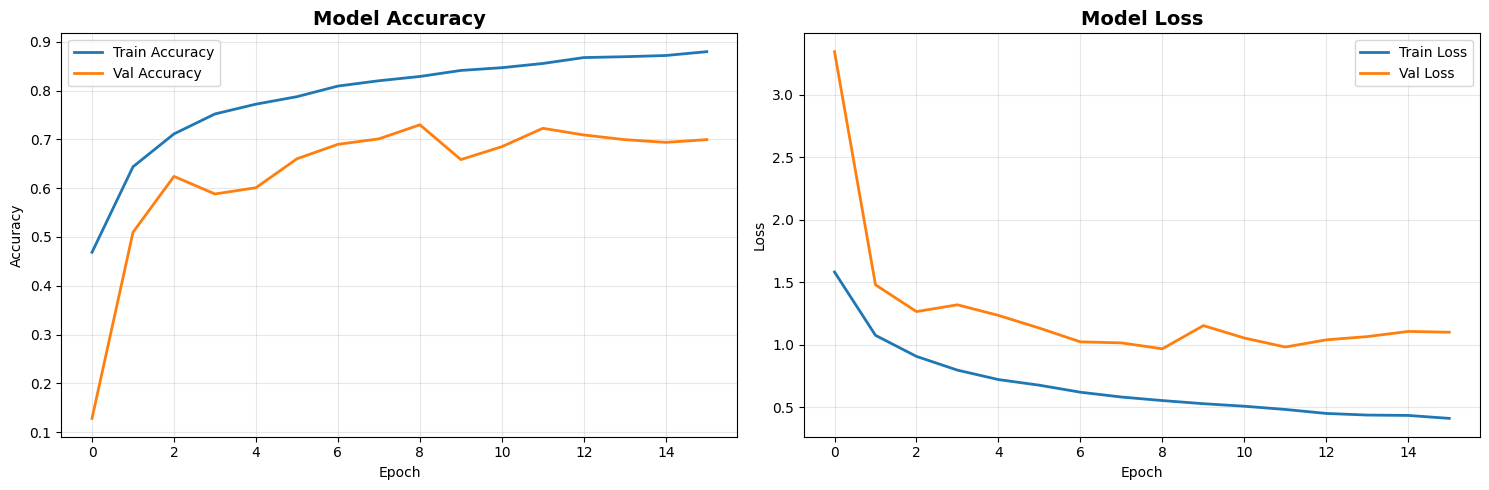


Best Val Accuracy : 0.7300
Final Train Accuracy: 0.8798


In [14]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history.history['accuracy'],     label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss',   linewidth=2)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nBest Val Accuracy : {max(history.history['val_accuracy']):.4f}")
print(f"Final Train Accuracy: {history.history['accuracy'][-1]:.4f}")

In [ ]:
# Load best model and evaluate
best_model = tf.keras.models.load_model(MODEL_SAVE_PATH)
print(f"Loaded best model from {MODEL_SAVE_PATH}")

test_loss, test_acc = best_model.evaluate(test_ds_prepared, verbose=1)
print(f"\nTest Accuracy : {test_acc:.4f}")
print(f"Test Loss     : {test_loss:.4f}")

✅ Loaded best model from best_tomato_disease_model.keras
41/41 [==============================] - 37s 257ms/step - loss: 0.9249 - accuracy: 0.7424

Test Accuracy : 0.7424
Test Loss     : 0.9249


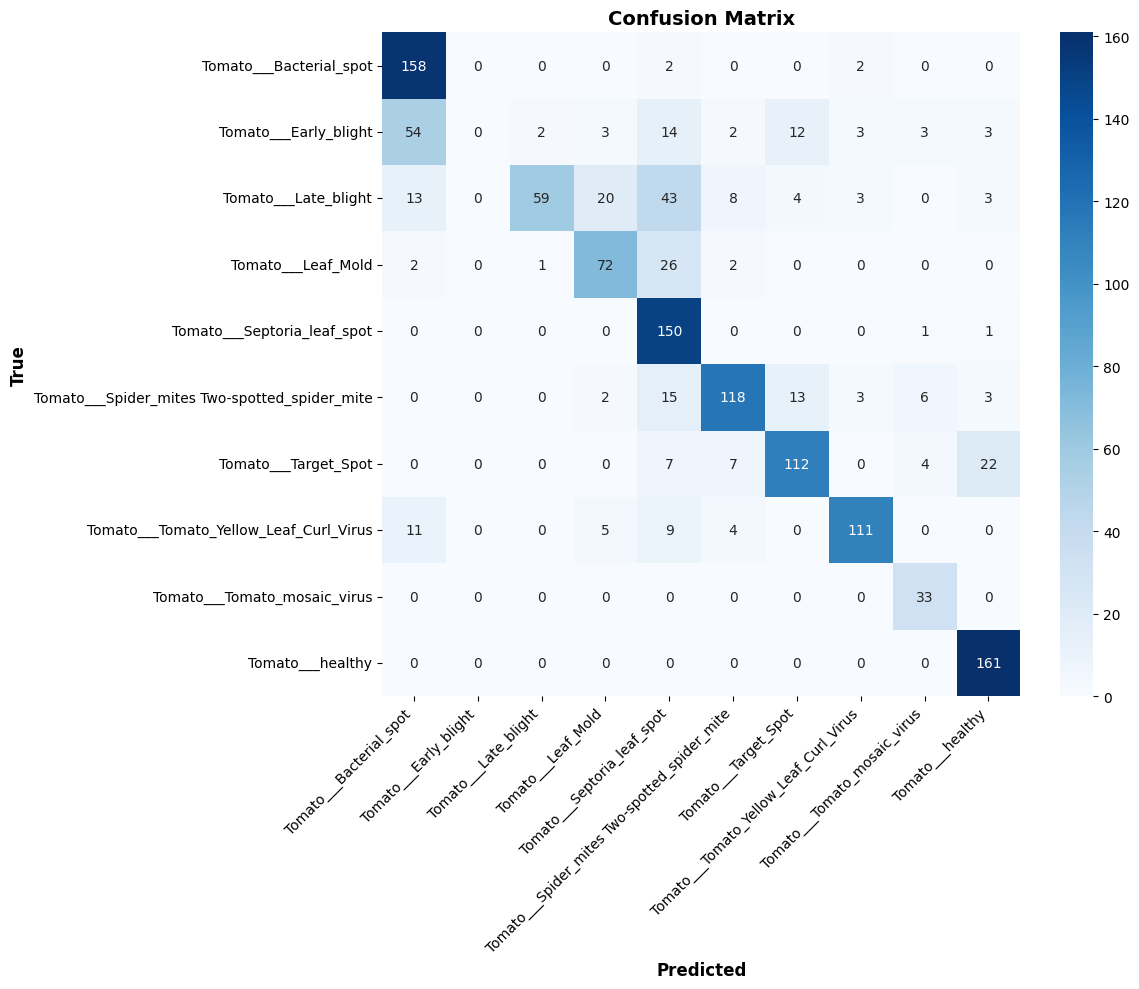


 CLASSIFICATION REPORT:

                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot     0.6639    0.9753    0.7900       162
                        Tomato___Early_blight     0.0000    0.0000    0.0000        96
                         Tomato___Late_blight     0.9516    0.3856    0.5488       153
                           Tomato___Leaf_Mold     0.7059    0.6990    0.7024       103
                  Tomato___Septoria_leaf_spot     0.5639    0.9868    0.7177       152
Tomato___Spider_mites Two-spotted_spider_mite     0.8369    0.7375    0.7841       160
                         Tomato___Target_Spot     0.7943    0.7368    0.7645       152
       Tomato___Tomato_Yellow_Leaf_Curl_Virus     0.9098    0.7929    0.8473       140
                 Tomato___Tomato_mosaic_virus     0.7021    1.0000    0.8250        33
                             Tomato___healthy     0.8342    1.0000    0.9096       161

               

d:\Major_Project_2\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Major_Project_2\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Major_Project_2\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [17]:
# Confusion Matrix + Classification Report
y_true, y_pred = [], []
for images, labels in test_ds_prepared:
    preds = best_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted', fontsize=12, fontweight='bold')
plt.ylabel('True',      fontsize=12, fontweight='bold')
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n CLASSIFICATION REPORT:\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

In [18]:
# Prediction function — same normalization as training
def predict_disease(img_path, model, class_names, top_k=3):
    from tensorflow.keras.preprocessing import image

    img       = image.load_img(img_path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0                        # same normalization as training
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array, verbose=0)[0]
    top_indices = np.argsort(predictions)[-top_k:][::-1]

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(image.load_img(img_path, target_size=(IMAGE_SIZE, IMAGE_SIZE)))
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    top_labels = [class_names[i] for i in top_indices]
    top_probs  = [predictions[i] * 100 for i in top_indices]
    colors     = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(top_indices))]
    bars = plt.barh(top_labels[::-1], top_probs[::-1], color=colors[::-1])
    plt.xlabel('Confidence (%)')
    plt.title('Top Predictions')
    plt.xlim(0, 100)
    for bar, prob in zip(bars, top_probs[::-1]):
        plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f'{prob:.1f}%', va='center')
    plt.tight_layout()
    plt.show()

    print(f"\n Predicted: {class_names[top_indices[0]]}")
    print(f"   Confidence: {predictions[top_indices[0]]*100:.2f}%")

print(" Prediction function ready")

 Prediction function ready


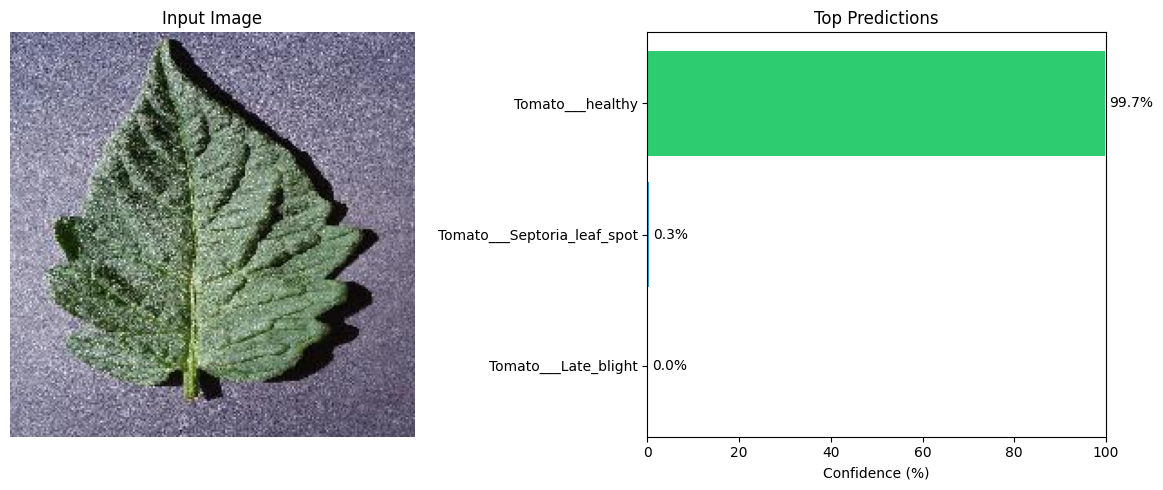


 Predicted: Tomato___healthy
   Confidence: 99.70%


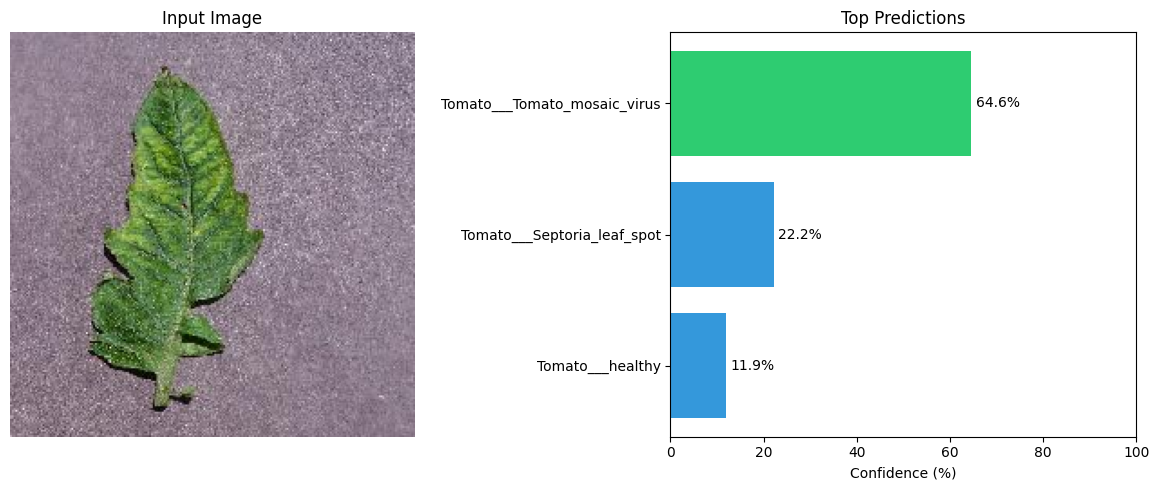


 Predicted: Tomato___Tomato_mosaic_virus
   Confidence: 64.64%


In [20]:
# Test predictions — change paths to your images
test_image_1 = r"D:\Major_Project_2\Dataset_Balanced\Tomato___healthy\0a31e630-0d98-416b-b0e4-88a88aad1dc5___RS_HL 9653.JPG"
test_image_2 = r"D:\Major_Project_2\Dataset_Balanced\Tomato___Tomato_mosaic_virus\0a7cc59f-b2b0-4201-9c4a-d91eca5c03a3___PSU_CG 2230.JPG"

for img_path in [test_image_1, test_image_2]:
    if os.path.exists(img_path):
        predict_disease(img_path, best_model, class_names)
    else:
        print(f"Image not found: {img_path}")

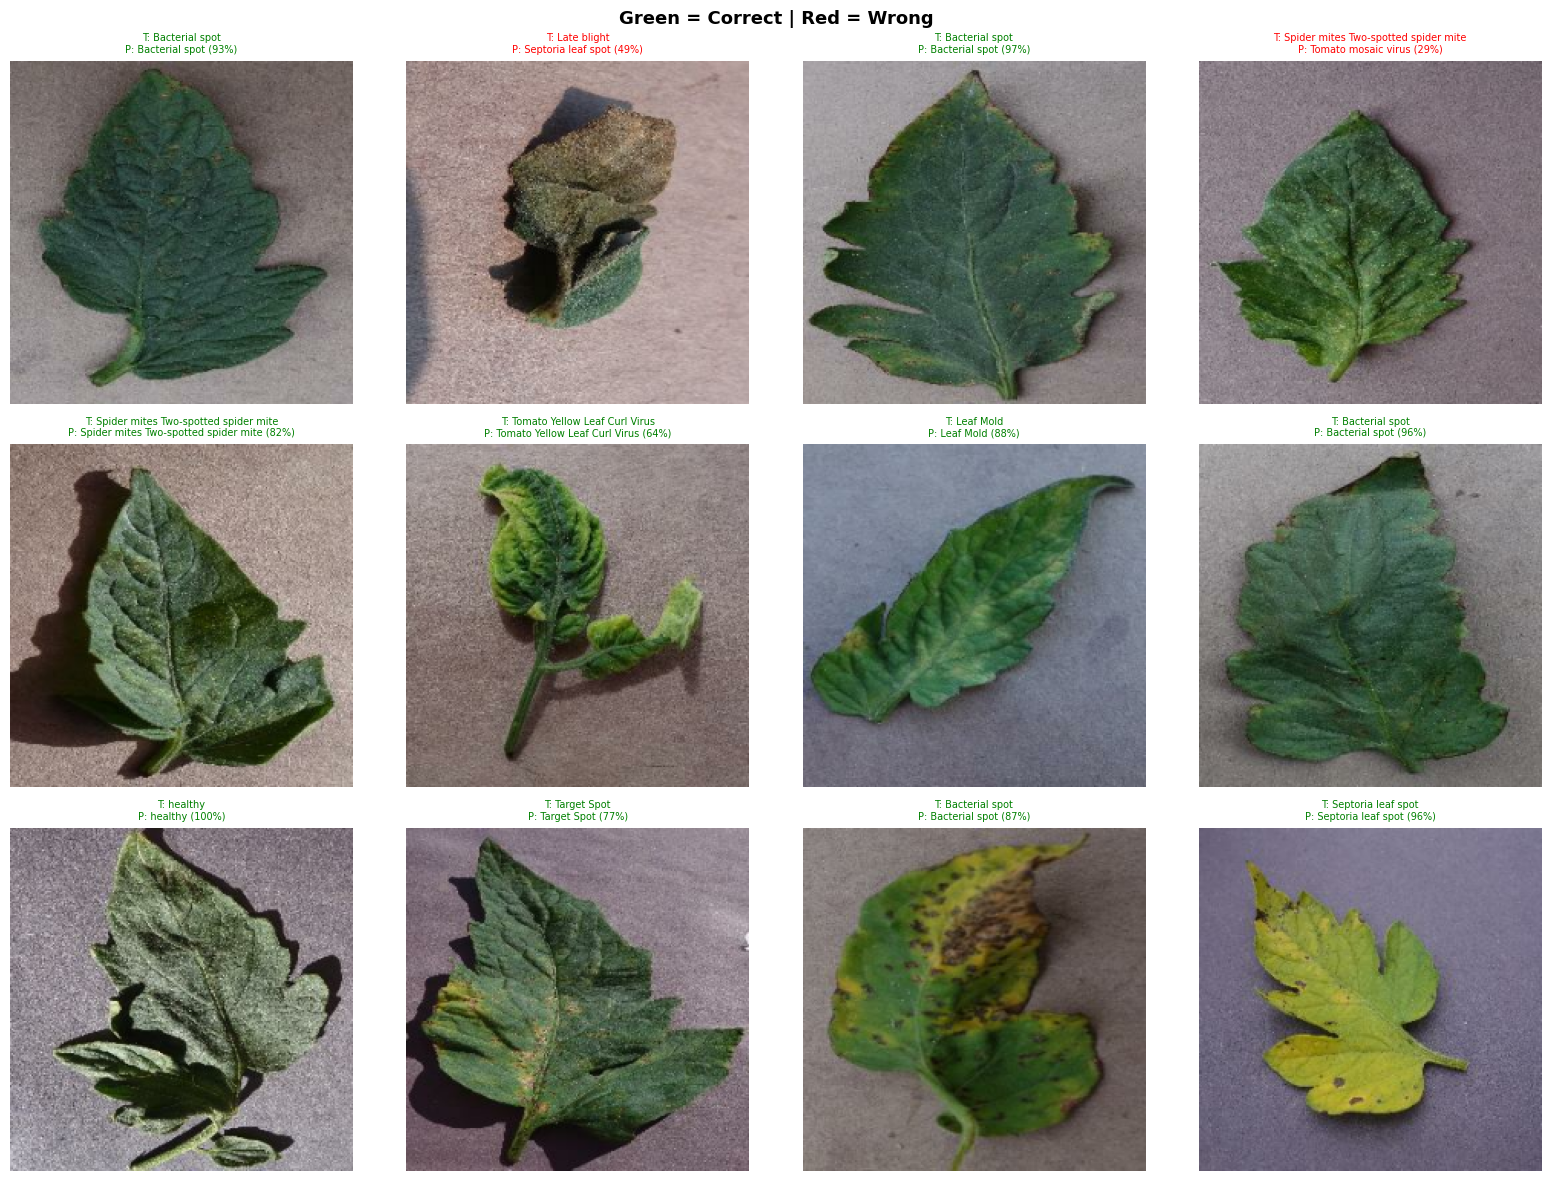

In [21]:
# Visualize predictions on test batch
plt.figure(figsize=(16, 12))
for images, labels in test_ds_prepared.take(1):
    preds   = best_model.predict(images, verbose=0)
    pred_labels = np.argmax(preds, axis=1)
    for i in range(min(12, len(images))):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow((images[i].numpy() * 255).astype('uint8'))
        true_label = class_names[labels[i]].split('___')[-1].replace('_', ' ')
        pred_label = class_names[pred_labels[i]].split('___')[-1].replace('_', ' ')
        conf       = preds[i][pred_labels[i]] * 100
        color      = 'green' if labels[i] == pred_labels[i] else 'red'
        ax.set_title(f"T: {true_label}\nP: {pred_label} ({conf:.0f}%)",
                     color=color, fontsize=7)
        plt.axis('off')
plt.suptitle('Green = Correct | Red = Wrong', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
# Save model in multiple formats
import json

# SavedModel format
best_model.save("saved_model_tomato_disease")
print("✅ SavedModel saved")

# TFLite format (for mobile)
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
with open("tomato_disease_model.tflite", 'wb') as f:
    f.write(tflite_model)
print("✅ TFLite model saved")

# Save class names
with open("class_names.json", 'w') as f:
    json.dump(class_names, f, indent=2)
print("✅ Class names saved")

print("\n🎉 All done!")
print(f"Final Test Accuracy: {test_acc:.2%}")

INFO:tensorflow:Assets written to: saved_model_tomato_disease\assets


INFO:tensorflow:Assets written to: saved_model_tomato_disease\assets


✅ SavedModel saved
INFO:tensorflow:Assets written to: C:\Users\hunny\AppData\Local\Temp\tmp4xqdtw5t\assets


INFO:tensorflow:Assets written to: C:\Users\hunny\AppData\Local\Temp\tmp4xqdtw5t\assets


✅ TFLite model saved
✅ Class names saved

🎉 All done!
Final Test Accuracy: 74.24%
